In [67]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# GPU 설정 확인
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("GPU Enabled")
    except RuntimeError as e:
        print(e)

# Import or install Sionna
try:

    import sionna.rt
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# Sionna RT의 주요 모듈 임포트
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera, RadioMapSolver, PathSolver
from sionna.rt.utils import r_hat, subcarrier_frequencies
from sionna.rt import scene as share_scene

GPU Enabled


In [68]:
# IEEE 802.11 OFDM 파라미터
carrier_frequency = 2.4e9  # 2.4 GHz (Hz 단위)
ch_bandwidth = 20e6        # 20 MHz (Hz 단위)
n_fft = 64                 # FFT 크기
cp_length = 16             # CP 길이 (샘플 수, 0.8us at 20MHz)
symbol_duration = 4e-6     # OFDM 심볼 길이 (초)
n_data = 48                # 데이터 서브캐리어 개수
n_pilot = 4                # 파일럿 서브캐리어 개수

In [69]:
# Sionna RT 내장 샘플 환경 사용
from sionna.rt import scene as sample_scene

# 예시 1: 작은 사무실 환경
scene = load_scene("/home/ccs-lab/yura.min/apartment/apartment.xml")

# 송신기(기지국) 안테나 배열 (1x1, 무지향성)
scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="cross")

# 수신기(단말) 안테나 배열 (1x1, 무지향성)
scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="cross")

# 송신기 생성 및 추가
tx = Transmitter(name="tx",
                 position=[-1.7, 1.7, 2.0],
                 look_at=[0, 0, 0],
                 display_radius=0.1)
scene.add(tx)
tx.array = scene.tx_array  # ← 이거 추가!
# 수신기 생성 및 추가 (시작 위치, Random Waypoint Model로 이후 이동)
rx = Receiver(name="rx",
              position=[-2.1, 5.8, 1.0],
              display_radius=0.1)
scene.add(rx)

tx.look_at(rx)  # 송신기가 수신기를 바라봄

# 3D 시각화용 카메라 설정

bird_cam = Camera(position=[0, 3, 15], look_at=[-3, 3, 0]) # 위에서 본 것


# IEEE 802.11 파라미터를 3D scene에 적용
scene.frequency = carrier_frequency
scene.bandwidth = ch_bandwidth



2025-12-04 15:18:10 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).


In [70]:
from sionna.rt import RadioMapSolver   # 꼭 추가!



max_depth = 4
cell_size = (0.1, 0.1)
samples_per_tx = 1000
resolution = (400, 400)

rm_solver = RadioMapSolver()
rm = rm_solver(scene,
               max_depth=max_depth,
               cell_size=cell_size,
               samples_per_tx=samples_per_tx)

output = scene.render(
    camera=bird_cam,
    radio_map=rm,
                  # radio_map과 경로를 동시에
    resolution=(800, 800),
    rm_metric="rss",
    rm_show_color_bar=True,

)

Processed 0/100 steps...
Processed 20/100 steps...
Processed 40/100 steps...
Processed 60/100 steps...
Processed 80/100 steps...
Rendering at step 83, Rx position: [-2.470718  4.879673  1.      ]
 -> Found 110 paths


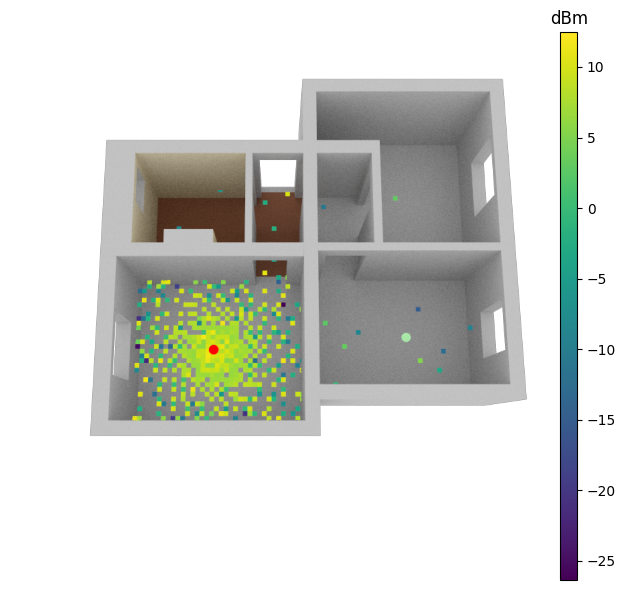

<Figure size 800x800 with 0 Axes>

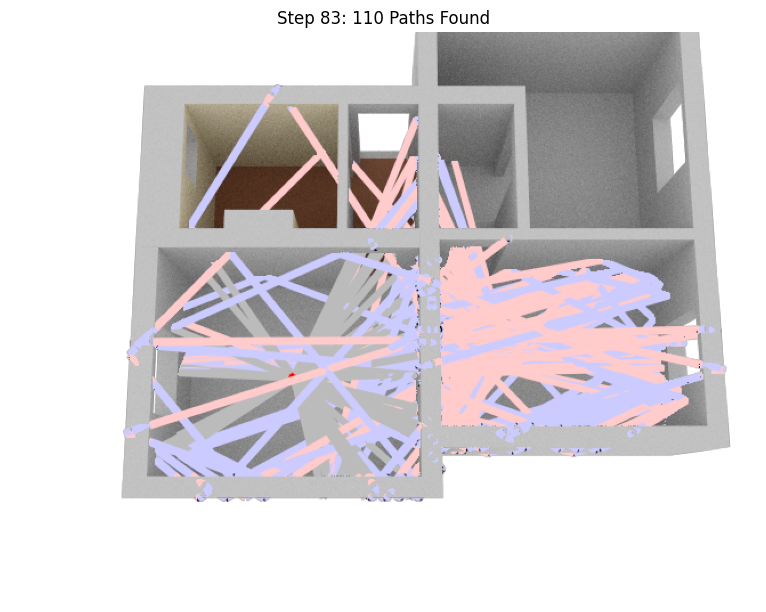

Simulation Complete. Collected 100 CIR snapshots and 100 CFR snapshots.

=== Trajectory positions and velocities ===
Step   0: pos = [-4.085751  5.263428  1.      ], vel = [ 1.9458294 -0.4623413  0.       ]
Step   1: pos = [-4.066293  5.258805  1.      ], vel = [ 1.9458294 -0.462389   0.       ]
Step   2: pos = [-4.0468345  5.254181   1.       ], vel = [ 1.9458294 -0.4623413  0.       ]
Step   3: pos = [-4.027376   5.2495575  1.       ], vel = [ 1.9458294 -0.4623413  0.       ]
Step   4: pos = [-4.007918  5.244934  1.      ], vel = [ 1.9458055 -0.462389   0.       ]
Step   5: pos = [-3.9884598  5.24031    1.       ], vel = [ 1.9458294 -0.4623413  0.       ]
Step   6: pos = [-3.9690015  5.235687   1.       ], vel = [ 1.9458294 -0.4623413  0.       ]
Step   7: pos = [-3.9495432  5.2310634  1.       ], vel = [ 1.9458055 -0.462389   0.       ]
Step   8: pos = [-3.9300852  5.2264395  1.       ], vel = [ 1.9458294 -0.4623413  0.       ]
Step   9: pos = [-3.910627  5.221816  1.      ], vel = 

In [71]:
# CFR 계산용 파라미터 (예: 20 MHz 대역, 64 서브캐리어)
num_subcarriers = 64
bandwidth = 20e6  # 20 MHz
subcarrier_freqs = scene.frequency + np.linspace(
    -bandwidth/2, bandwidth/2, num_subcarriers
)

# Random Waypoint 생성 (방 내부로 제한)
def generate_random_waypoint_trajectory(
    area_bounds=[[-5, -0.5], [1, 7]],
    height=1.0,
    v=2.0,
    duration=1.0,
    dt=0.01,  # 시간 간격
    threshold=1  # 목표 도달 판정 거리
):
    num_steps = int(duration / dt)
    positions = []

    # 초기 위치를 area_bounds 내에서 랜덤으로 설정
    x = np.random.uniform(area_bounds[0][0], area_bounds[0][1])
    y = np.random.uniform(area_bounds[1][0], area_bounds[1][1])
    pos = np.array([x, y])

    goal = None

    for _ in range(num_steps):
        if goal is None or np.linalg.norm(goal - pos) < threshold:
            # 새 목표 지점 샘플링
            x = np.random.uniform(area_bounds[0][0], area_bounds[0][1])
            y = np.random.uniform(area_bounds[1][0], area_bounds[1][1])
            goal = np.array([x, y])
            direction = goal - pos
            direction /= np.linalg.norm(direction)

        pos = pos + v * dt * direction
        positions.append([pos[0], pos[1], height])

    positions = np.array(positions, dtype=np.float32)
    return positions, dt   # dt 같이 반환


# 궤적 및 시간 간격 가져오기
traj_positions, sim_dt = generate_random_waypoint_trajectory()

# Velocity 추출 (finite difference)
velocities = (traj_positions[1:] - traj_positions[:-1]) / sim_dt
velocities = np.vstack([velocities, velocities[-1]])  # 마지막 스텝 보정

path_solver = PathSolver()

# 시각화 샘플링: 전체 스텝 중 1개만 렌더링
np.random.seed(42)
render_indices = np.random.choice(len(traj_positions), size=1, replace=False)

cir_list = []   # CIR 스냅샷 저장
cfr_list = []   # CFR 스냅샷 저장

# 속도 부여 (Doppler 반영)
rx.velocity = velocities[i].tolist()

for i, pos in enumerate(traj_positions):
    try:
        # 이전 Rx 제거 (처음엔 KeyError 날 수 있어서 예외 처리)
        try:
            scene.remove("rx")
        except KeyError:
            pass

        rx = Receiver(name="rx", position=pos.tolist(), display_radius=0.2)
        scene.add(rx)
        tx.look_at(rx)

        paths = path_solver(
            scene=scene,
            max_depth=20,              # 속도 최적화
            max_num_paths_per_src=1000000,
            los=True,
            specular_reflection=True,
            diffuse_reflection=True,
            refraction=True,
            synthetic_array=False,
            seed=42
        )


        # 선택된 스텝만 경로 시각화
        if i in render_indices:
            a_check, _ = paths.cir(normalize_delays=True)
            a_check = a_check.numpy() if hasattr(a_check, "numpy") else np.array(a_check)
            num_paths_found = a_check.shape[-2]

            print(f"Rendering at step {i}, Rx position: {pos}")
            print(f" -> Found {num_paths_found} paths")

            plt.figure(figsize=(8, 8))
            if num_paths_found > 0:
                scene.render(camera=bird_cam, paths=paths, show_devices=True)
                plt.title(f"Step {i}: {num_paths_found} Paths Found")
            else:
                scene.render(camera=bird_cam, show_devices=True)
                plt.title("No Paths Found")
            plt.show()

        # ----------------------
        # CIR 수집
        # ----------------------
        a, tau = paths.cir(normalize_delays=True)
        a_np = a.numpy() if hasattr(a, "numpy") else np.array(a)
        tau_np = tau.numpy() if hasattr(tau, "numpy") else np.array(tau)
        cir_list.append((a_np, tau_np))

        # ----------------------
        # CFR 수집
        # ----------------------
        h_f = paths.cfr(subcarrier_freqs)   # subcarrier_freqs는 미리 정의되어 있어야 함
        h_f_np = h_f.numpy() if hasattr(h_f, "numpy") else np.array(h_f)
        cfr_list.append(h_f_np)

    except Exception as e:
        print(f"Error at step {i}: {e}")
        break

    if i % 20 == 0:
        print(f"Processed {i}/{len(traj_positions)} steps...")

print(f"Simulation Complete. Collected {len(cir_list)} CIR snapshots and {len(cfr_list)} CFR snapshots.")

# -------------------------------------------------------------------------
# 6. traj_positions[i], velocities[i] 출력
# -------------------------------------------------------------------------
print("\n=== Trajectory positions and velocities ===")
for i in range(len(traj_positions)):
    print(f"Step {i:3d}: pos = {traj_positions[i]}, vel = {velocities[i]}")


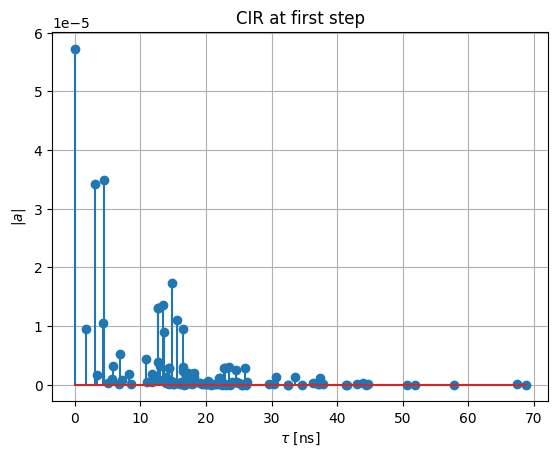

In [72]:
# CIR 시퀀스 수집 전용
# 1) 시퀀스 저장용 빈 리스트 준비
a_np_list   = []   # 나중에 amp(복소 이득) 시퀀스를 담을 리스트
tau_np_list = []   # 나중에 delay(지연) 시퀀스를 담을 리스트
a_np, tau_np = paths.cir(normalize_delays=True, out_type="numpy")
a_np_list.append(a_np)
tau_np_list.append(tau_np)


# 예: 첫 번째 스텝의 복소 이득(a)의 크기(절댓값)만 추출
t = tau_np_list[0][0,0,0,0,:]/1e-9
a_abs = np.abs(a_np_list[0])[0,0,0,0,:,0]

plt.figure()
plt.title("CIR at first step")
plt.stem(t, a_abs)
plt.xlabel(r"$\tau$ [ns]")
plt.ylabel(r"$|a|$")
plt.grid(True)
plt.show()


Shape of h_freq:  (1, 2, 1, 2, 1, 64)


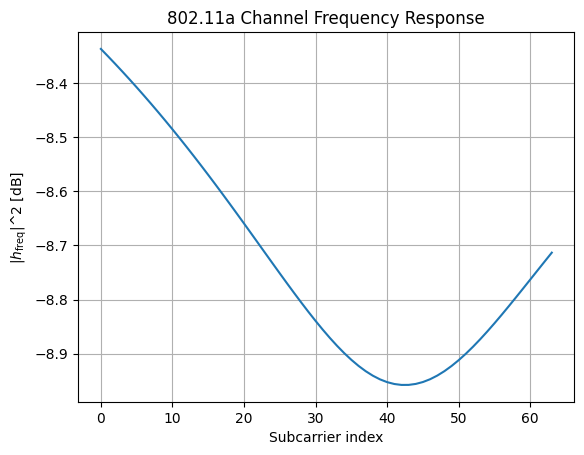

In [73]:
# OFDM system parameters for 802.11a
num_subcarriers    = 64               # 전체 서브캐리어 개수
subcarrier_spacing = 312.5e3          # 서브캐리어 간격 312.5 kHz

# Compute frequencies of subcarriers relative to carrier frequency
#    carrier_frequency 기준으로 각 서브캐리어의 상대 주파수를 반환
#    반환 shape: (num_subcarriers,)
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

# Compute channel frequency response from paths
h_freq = paths.cfr(frequencies=frequencies,
                   normalize=False,
                   normalize_delays=True,
                   out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, num_subcarriers]
print("Shape of h_freq: ", h_freq.shape)

# Plot CFR
plt.figure()
plt.plot(np.log10(np.abs(h_freq)[0,0,0,0,0,:] ** 2));
plt.xlabel("Subcarrier index")
plt.ylabel(r"|$h_\text{freq}$|^2 [dB]")
plt.title("802.11a Channel Frequency Response")
plt.grid(True)
plt.show()


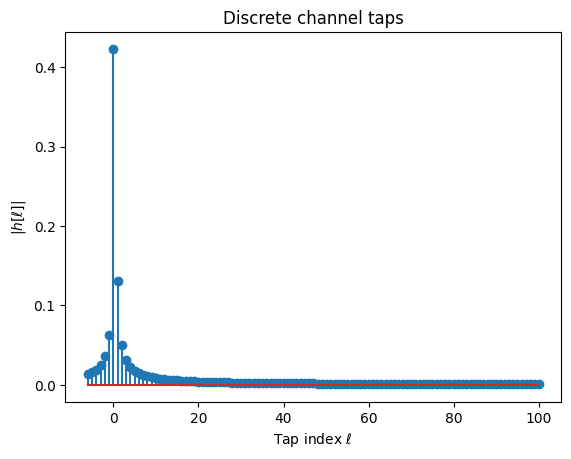

In [74]:
(frequencies[-1] - frequencies[0]) / 1e6 #서브캐리어 전체 대역폭 계산, Hz에서 MHz

taps = paths.taps(bandwidth=ch_bandwidth,
                      l_min=-6, l_max=100,
                      normalize=True,
                      normalize_delays=True,
                      out_type="numpy")

# 시퀀스 시각화 (PDP heatmap)
plt.figure()
plt.stem(np.arange(-6, 101), np.abs(taps)[0,0,0,0,0]);
plt.xlabel(r"Tap index $\ell$");
plt.ylabel(r"|$h[\ell]|$");
plt.title("Discrete channel taps");
plt.show()


Calculating Time-Varying Channel Frequency Response from collected CFR snapshots...
Original Shape of cfr_array:  (100, 2, 1, 2, 1, 2, 1, 64)
Reshaped to 2D (Time, Feature):  (100, 512)


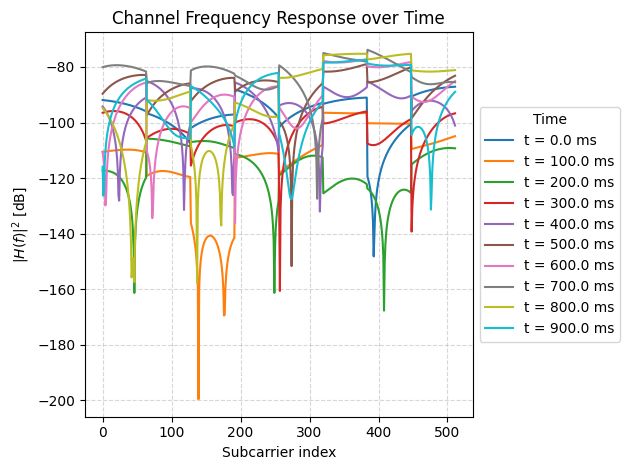

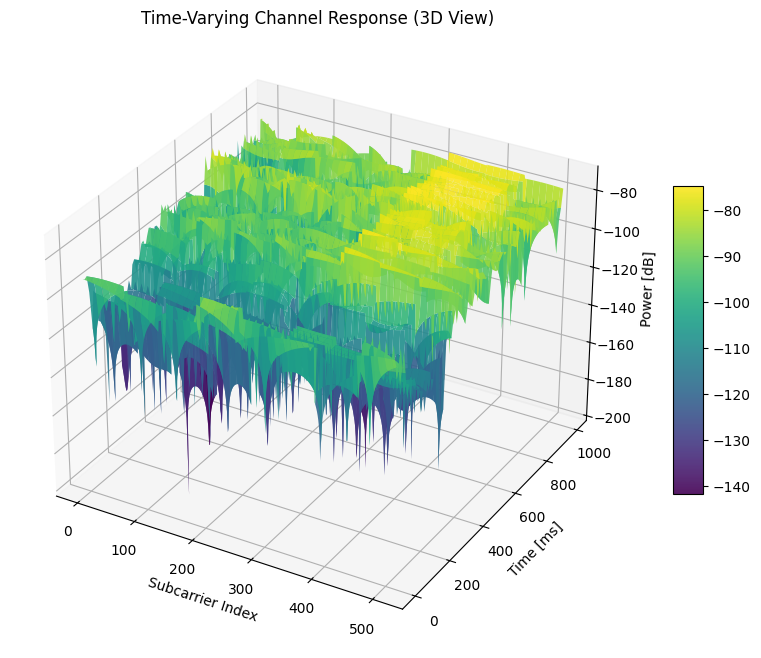


Generating Dataset...
X_data shape: (90, 10, 512)
y_data shape: (90, 512)


In [75]:
import matplotlib.pyplot as plt
import numpy as np
# from sionna.rt.utils import subcarrier_frequencies  # 주파수축이 필요하면 사용

# 7. Time-Variant CFR (시간에 따른 주파수 응답 변화) - cfr_list 기반

print("Calculating Time-Varying Channel Frequency Response from collected CFR snapshots...")

# 1. cfr_list -> 배열로 변환
cfr_array = np.array(cfr_list)     # 예: (T, 1, 1, 1, 64) 혹은 (T, 1, 1, 1, 1, 64) 등
print("Original Shape of cfr_array: ", cfr_array.shape)

# [핵심 수정] 첫 번째 축 = 시간, 나머지는 전부 한 축으로 평탄화
num_time_steps = cfr_array.shape[0]
cfr_2d = cfr_array.reshape(num_time_steps, -1)   # (T, feature_dim)
print("Reshaped to 2D (Time, Feature): ", cfr_2d.shape)

# 시간/서브캐리어 개수 (여기서 두 번째 축은 '서브캐리어+기타 축' 통합 피처)
num_time_steps, num_subcarriers = cfr_2d.shape

# 시뮬레이션에서 사용한 시간 간격과 샘플링 주파수
sampling_frequency = 1.0 / sim_dt   # [Hz]  예: dt=0.01이면 100 Hz

# Power [dB] 계산
cfr_power_db = 10 * np.log10(np.abs(cfr_2d)**2 + 1e-20)

# 대략 10개 정도 스냅샷만 그리도록 간격 설정
step = max(1, num_time_steps // 10)

for idx in range(0, num_time_steps, step):
    time_ms = idx * sim_dt * 1000.0
    plt.plot(cfr_power_db[idx, :], label=f't = {time_ms:.1f} ms')

plt.xlabel("Subcarrier index")
plt.ylabel(r"$|H(f)|^2$ [dB]")
plt.title("Channel Frequency Response over Time")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Time")
plt.tight_layout()
plt.show()



# ---------------------------------------------------
# 3. 3D Surface 시각화 (전체적인 변화 확인)
# ---------------------------------------------------
try:
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    # X: subcarrier index, Y: time[ms]
    time_axis_ms = np.arange(num_time_steps) * sim_dt * 1000.0
    X, Y = np.meshgrid(np.arange(num_subcarriers), time_axis_ms)

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(X, Y, cfr_power_db,
                           cmap='viridis', edgecolor='none', alpha=0.9)

    ax.set_xlabel('Subcarrier Index')
    ax.set_ylabel('Time [ms]')
    ax.set_zlabel('Power [dB]')
    ax.set_title('Time-Varying Channel Response (3D View)')
    fig.colorbar(surf, shrink=0.5, aspect=10)
    plt.show()
except Exception as e:
    print(f"3D plot skipped: {e}")

# ---------------------------------------------------
# 4. 데이터셋 생성 및 저장 (Sliding Window)
#    과거 10개의 CSI를 보고 미래 1개의 CSI를 예측
# ---------------------------------------------------
print("\nGenerating Dataset...")

seq_len = 10       # 과거 10 스텝
pred_horizon = 1   # 미래 1 스텝 예측

X_data, y_data = [], []

for t in range(len(cfr_2d) - seq_len - pred_horizon + 1):
    # 입력: (10, N_subcarriers)
    X_data.append(cfr_2d[t : t + seq_len])
    # 정답: (N_subcarriers,)
    y_data.append(cfr_2d[t + seq_len + pred_horizon - 1])

X_data = np.stack(X_data)
y_data = np.stack(y_data)

print("X_data shape:", X_data.shape)  # (num_samples, 10, N_subcarriers)
print("y_data shape:", y_data.shape)  # (num_samples, N_subcarriers)


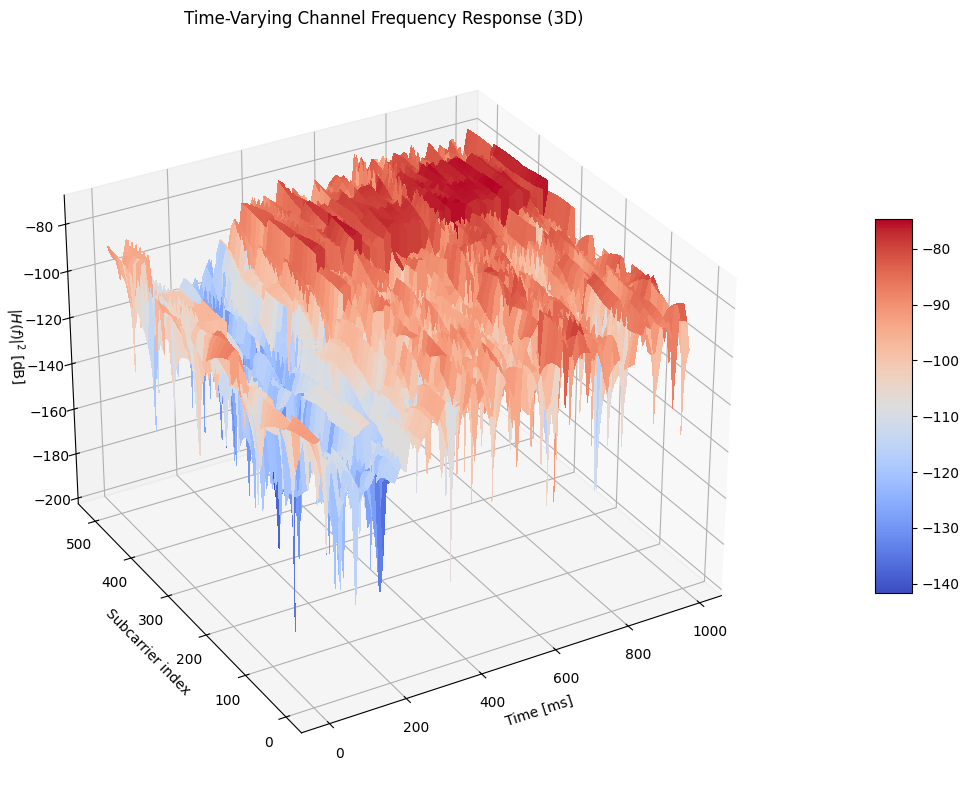

In [76]:
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import numpy as np

# 1. 3D 플롯을 위한 데이터 준비
# cfr_2d shape: (Time, Subcarrier)  예: (T, 64)
num_time_steps, num_subcarriers = cfr_2d.shape

# 시간축을 실제 ms 로 표현 (sim_dt는 앞에서 trajectory 생성할 때 받은 dt)
time_axis_ms = np.arange(num_time_steps) * sim_dt * 1000.0
subcarrier_axis = np.arange(num_subcarriers)

# X, Y 격자 (Time, Subcarrier)
X, Y = np.meshgrid(time_axis_ms, subcarrier_axis)   # shape: (N_subcarriers, T)

# Z 축 데이터: (Subcarrier, Time) 모양으로 맞춰주기 위해 transpose
Z = cfr_power_db.T   # (N_subcarriers, T)

# 2. 3D Surface Plot 그리기
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X, Y, Z,
    cmap=cm.coolwarm,
    linewidth=0,
    antialiased=False
)

ax.set_xlabel("Time [ms]")
ax.set_ylabel("Subcarrier index")
ax.set_zlabel(r"$|H(f)|^2$ [dB]")
ax.set_title("Time-Varying Channel Frequency Response (3D)")

fig.colorbar(surf, shrink=0.5, aspect=10, pad=0.1)

ax.view_init(elev=30, azim=-120)

plt.tight_layout()
plt.show()


In [79]:
import numpy as np
import scipy.io

print("=== Saving cfr_list to .mat ===")

# --------------------------------------------------
# 1. cfr_list 변환 (리스트 -> 넘파이 배열)
# --------------------------------------------------
# cfr_list는 루프를 돌 때마다 append 되었으므로
# np.array로 묶으면 (Time_Steps, ...) 형태가 됩니다.
cfr_collected = np.array(cfr_list)

# Sionna의 CFR 출력은 차원이 많습니다 (예: [1, 1, 1, 1, 64, 1] 등).
# np.squeeze()를 사용해 크기가 1인 차원을 모두 제거합니다.
# 결과적으로 (Time_Steps, Num_Subcarriers) 형태, 예: (100, 64)가 되어야 합니다.
cfr_final = np.squeeze(cfr_collected)

# 차원 확인 (매우 중요!)
print(f"Original Stacked Shape: {cfr_collected.shape}")
print(f"Final CFR Shape (Target: [Time, Subcarriers]): {cfr_final.shape}")

# 혹시 차원이 (Subcarriers, Time) 등으로 뒤집혀 있다면 전치(Transpose) 필요
if cfr_final.shape[0] != len(velocities):
    print("Warning: Time dimension mismatch. Trying transpose...")
    cfr_final = cfr_final.T
    print(f"Transposed Shape: {cfr_final.shape}")

# --------------------------------------------------
# 2. .mat 파일로 저장
# --------------------------------------------------
mat_data = {
    'CFR': cfr_final,                  # [수정] 루프에서 수집한 실제 데이터
    'velocity': velocities,            # 궤적 속도
    
    # 부가 정보 (기존 변수명 활용)
    'num_subcarriers': num_subcarriers,
    # 만약 변수가 없다면 직접 값 입력 (예: 312500.0)
    'subcarrier_spacing': subcarrier_spacing if 'subcarrier_spacing' in locals() else 312.5e3,
    'sampling_frequency': 1.0/sim_dt if 'sim_dt' in locals() else 1000.0,
    'time_axis': np.arange(len(cfr_final)) * (sim_dt if 'sim_dt' in locals() else 0.01)
}

file_name = "indoor_csi_dataset_final.mat"
scipy.io.savemat(file_name, mat_data)
print(f"\nSuccessfully saved to {file_name}")

# --------------------------------------------------
# 3. 데이터 검증 (시간에 따른 변화 확인)
# --------------------------------------------------
diff = np.sum(np.abs(cfr_final[0] - cfr_final[-1]))
print(f"Diff between t=0 and t=end: {diff:.6f}")

if diff > 1e-9:
    print(">> OK: 채널이 시간에 따라 변하고 있습니다.")
else:
    print(">> WARNING: 여전히 채널이 정적입니다. cfr_list가 제대로 수집되었는지 확인하세요.")

=== Saving cfr_list to .mat ===
Original Stacked Shape: (100, 2, 1, 2, 1, 2, 1, 64)
Final CFR Shape (Target: [Time, Subcarriers]): (100, 2, 2, 2, 64)

Successfully saved to indoor_csi_dataset_final.mat
Diff between t=0 and t=end: 0.055978
>> OK: 채널이 시간에 따라 변하고 있습니다.


In [80]:
print("velocities.shape:", np.array(velocities).shape)
print("first 5 samples:", velocities[:5])


velocities.shape: (100, 3)
first 5 samples: [[ 1.9458294 -0.4623413  0.       ]
 [ 1.9458294 -0.462389   0.       ]
 [ 1.9458294 -0.4623413  0.       ]
 [ 1.9458294 -0.4623413  0.       ]
 [ 1.9458055 -0.462389   0.       ]]
